# YOLO11-S + CBAM: Wildfire Smoke & Fire Detection
**Architecture:** YOLO11-S with a single CBAM module injected after C2PSA (layer 10)  
**Goal:** Early smoke/fire detection with minimized false positives from environmental confounders  
**Datasets:** D-Fire + NEMO + PyroNear (pyro-sdis) → unified corpus of ~55,698 images

---
## 1. Setup

In [1]:
!pip install ultralytics pycocotools datasets matplotlib opencv-python-headless -q

import os, gc, json, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
import cv2

print(f"Torch       : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
print(f"Device      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("Libraries loaded ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.7 MB/s eta 0:00:00
Torch       : 2.10.0+cu128
CUDA        : True
Device      : Tesla T4
Libraries loaded ✅


---
## 2. D-Fire — Load, Filter & Verify

**Source:** `github.com/gaia-solutions-on-demand/DFireDataset` (Kaggle: `sayedgamal99/smoke-fire-detection-yolo`)  
**Size:** 21,527 RGB images, 26,557 bounding boxes — filtered to ~18,700 by rejecting close-up shots  
**Classes:** 0=smoke, 1=fire (author convention)  
**Hard negatives:** ~9,838 images of lamp glare, sun glare, environmental confusion

In [2]:
DFIRE_PATH  = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data"
CLASS_NAMES = ["smoke", "fire"]
COLORS      = [(0.39, 0.71, 1.0), (1.0, 0.31, 0.0)]

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    if img_dir.exists():
        imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
        lbls = list(lbl_dir.glob("*.txt"))
        print(f"D-Fire {split:5s}: {len(imgs):6d} images | {len(lbls):6d} labels")
    else:
        print(f"D-Fire {split}: path not found")

D-Fire train:  14122 images |  14122 labels
D-Fire val  :   3099 images |   3099 labels
D-Fire test :   4306 images |   4306 labels


In [3]:
def is_distant_shot(label_path, max_box_area=0.40):
    """
    Returns True if image is a distant/tower-camera shot.
    Rejects images where any bounding box covers >40% of the frame.
    Close-up shots (kitchen fires, indoor) have large boxes;
    distant wildfire tower shots have small boxes.
    """
    lbl = Path(label_path)
    if not lbl.exists():
        return True  # no label = negative sample, keep
    with open(lbl) as f:
        lines = f.readlines()
    if not lines or all(l.strip() == '' for l in lines):
        return True  # empty label = negative, keep
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        _, xc, yc, bw, bh = map(float, parts)
        if bw * bh > max_box_area:
            return False
    return True


print("Filtering D-Fire (max box area = 40%)...")
dfire_kept     = {}
dfire_rejected = {}

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    kept, rejected = [], []
    for img_path in sorted(img_dir.glob("*.jpg")):
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if is_distant_shot(lbl_path):
            kept.append(img_path)
        else:
            rejected.append(img_path)
    dfire_kept[split]     = kept
    dfire_rejected[split] = rejected
    pct = len(rejected) / max(len(kept) + len(rejected), 1) * 100
    print(f"  {split:5s}: kept {len(kept):6d} | rejected {len(rejected):5d} ({pct:.1f}% removed)")

total_kept     = sum(len(v) for v in dfire_kept.values())
total_rejected = sum(len(v) for v in dfire_rejected.values())
print(f"\nTotal kept: {total_kept} | rejected: {total_rejected} "
      f"({total_rejected/(total_kept+total_rejected)*100:.1f}% overall)")

Filtering D-Fire (max box area = 40%)...
  train: kept  12270 | rejected  1852 (13.1% removed)
  val  : kept   2676 | rejected   423 (13.6% removed)
  test : kept   3754 | rejected   552 (12.8% removed)

Total kept: 18700 | rejected: 2827 (13.1% overall)


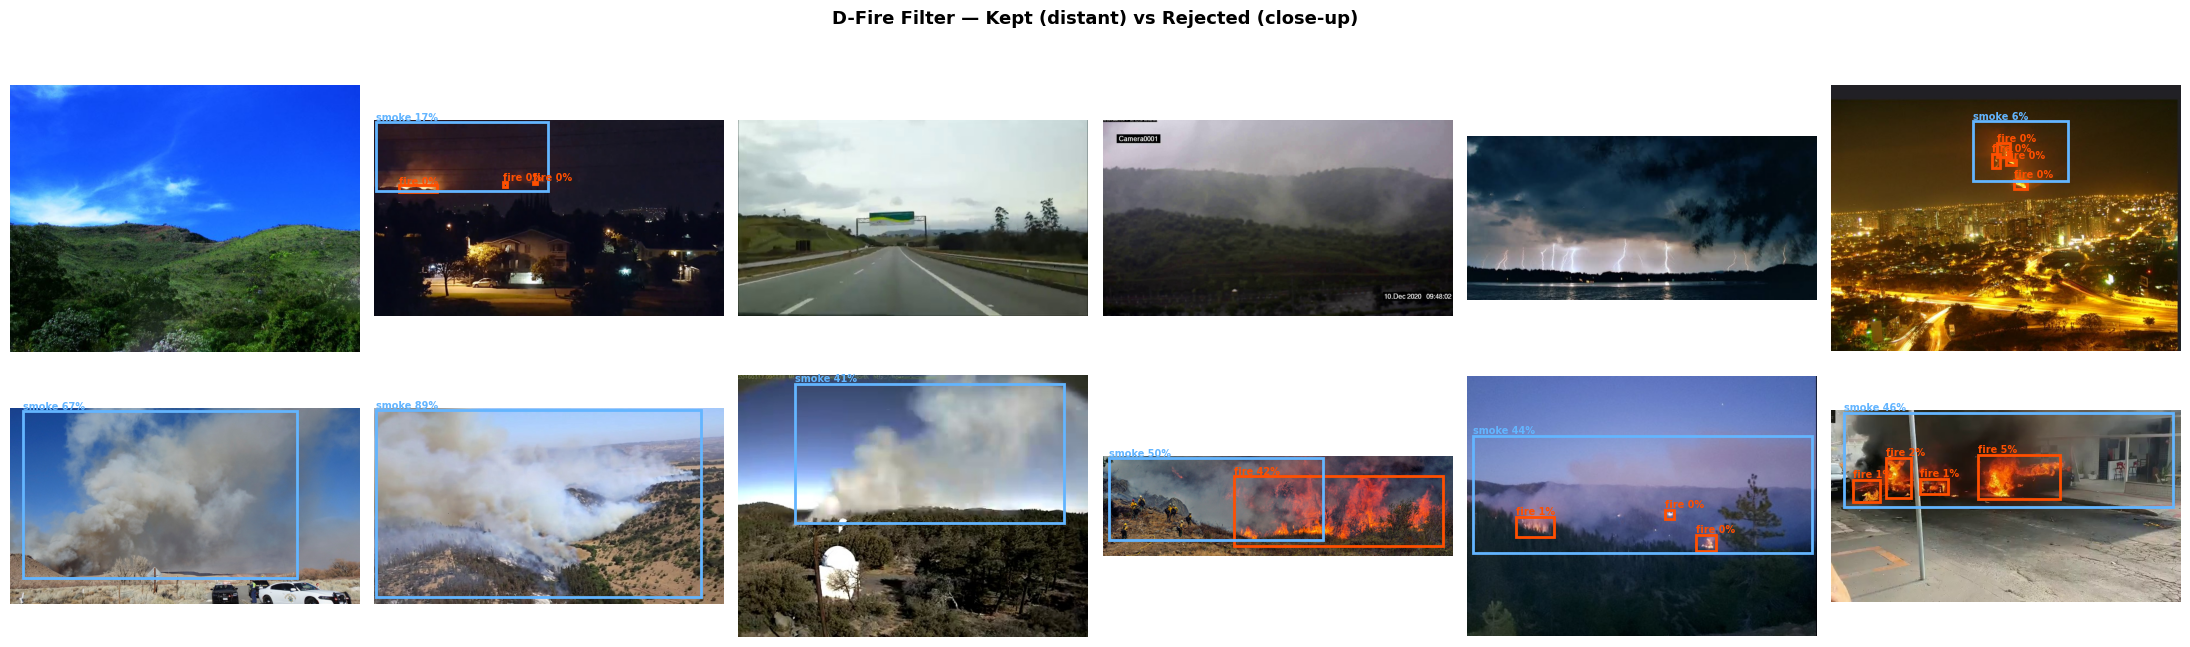

In [4]:
# Visual check: kept (distant) vs rejected (close-up)
def draw_boxes(ax, img_path, lbl_path):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    ax.imshow(img)
    if Path(lbl_path).exists():
        for line in open(lbl_path).readlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:])
            x1, y1 = (xc - bw/2)*W, (yc - bh/2)*H
            c = COLORS[cls % len(COLORS)]
            ax.add_patch(patches.Rectangle((x1, y1), bw*W, bh*H,
                         linewidth=2, edgecolor=c, facecolor='none'))
            ax.text(x1, y1-4, f"{CLASS_NAMES[cls]} {bw*bh*100:.0f}%",
                    color=c, fontsize=7, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(2, 6, figsize=(22, 7))
fig.suptitle("D-Fire Filter — Kept (distant) vs Rejected (close-up)",
             fontsize=13, fontweight='bold')

for i, img_path in enumerate(random.sample(dfire_kept["train"], min(6, len(dfire_kept["train"])))):
    lbl = Path(DFIRE_PATH) / "train" / "labels" / f"{img_path.stem}.txt"
    draw_boxes(axes[0][i], img_path, lbl)
    if i == 0: axes[0][i].set_ylabel("KEPT", fontsize=10, fontweight='bold', color='green')

for i, img_path in enumerate(random.sample(dfire_rejected["train"], min(6, len(dfire_rejected["train"])))):
    lbl = Path(DFIRE_PATH) / "train" / "labels" / f"{img_path.stem}.txt"
    draw_boxes(axes[1][i], img_path, lbl)
    if i == 0: axes[1][i].set_ylabel("REJECTED", fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

---
## 3. NEMO — Convert COCO JSON → YOLO

**Source:** `github.com/SayBender/Nemo` (Kaggle: `werus23/nevada-smoke-detection-data`)  
**Size:** 2,934 images, 4,522 labeled smoke bounding boxes  
**Classes:** Smoke only (low/mid/high density → collapsed to class 0)

In [5]:
NEMO_BASE       = "/kaggle/input/datasets/werus23/nevada-smoke-detection-data"
NEMO_TRAIN_IMGS = f"{NEMO_BASE}/NEMO data/train_images"
NEMO_VAL_IMGS   = f"{NEMO_BASE}/NEMO data/val_images"
NEMO_TRAIN_JSON = f"{NEMO_BASE}/NEMO data/annotation_train.json"
NEMO_VAL_JSON   = f"{NEMO_BASE}/NEMO data/annotation_val.json"
NEMO_2023_IMGS  = f"{NEMO_BASE}/20-23_daytime_images/daytime images"
NEMO_2023_JSON  = f"{NEMO_BASE}/20-23_daytime_label.json"


def coco_to_yolo(json_path, img_src_dir, img_dst_dir, lbl_dst_dir, smoke_class=0):
    """Convert COCO JSON annotations → YOLO format. All smoke classes → class 0."""
    os.makedirs(img_dst_dir, exist_ok=True)
    os.makedirs(lbl_dst_dir, exist_ok=True)
    with open(json_path) as f:
        coco = json.load(f)
    img_map = {img["id"]: img for img in coco["images"]}
    ann_map = {}
    for ann in coco["annotations"]:
        ann_map.setdefault(ann["image_id"], []).append(ann)
    converted = copied = 0
    for img_id, img_info in img_map.items():
        W, H   = img_info["width"], img_info["height"]
        fname  = Path(img_info["file_name"]).stem
        src    = Path(img_src_dir) / Path(img_info["file_name"]).name
        if src.exists():
            shutil.copy2(src, Path(img_dst_dir) / src.name)
            copied += 1
        lines = []
        for ann in ann_map.get(img_id, []):
            x, y, w, h = ann["bbox"]
            xc, yc = (x + w/2)/W, (y + h/2)/H
            wn, hn = w/W, h/H
            lines.append(f"{smoke_class} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")
        with open(Path(lbl_dst_dir) / f"{fname}.txt", "w") as f:
            f.write("\n".join(lines))
        converted += 1
    print(f"  Converted {converted} labels, copied {copied} images")


print("Converting NEMO train...")
coco_to_yolo(NEMO_TRAIN_JSON, NEMO_TRAIN_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")

print("Converting NEMO val...")
coco_to_yolo(NEMO_VAL_JSON, NEMO_VAL_IMGS,
             "/kaggle/working/nemo_yolo/images/val",
             "/kaggle/working/nemo_yolo/labels/val")

print("Merging 20-23 daytime into train...")
coco_to_yolo(NEMO_2023_JSON, NEMO_2023_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")

print("\nNEMO conversion complete:")
for split in ["train", "val"]:
    imgs = list(Path(f"/kaggle/working/nemo_yolo/images/{split}").glob("*.jpg"))
    lbls = list(Path(f"/kaggle/working/nemo_yolo/labels/{split}").glob("*.txt"))
    print(f"  {split}: {len(imgs)} images | {len(lbls)} labels")

Converting NEMO train...
  Converted 2680 labels, copied 2680 images
Converting NEMO val...
  Converted 250 labels, copied 250 images
Merging 20-23 daytime into train...
  Converted 432 labels, copied 432 images

NEMO conversion complete:
  train: 3112 images | 3112 labels
  val: 250 images | 250 labels


---
## 4. PyroNear (pyro-sdis) — Load from HuggingFace & Convert to YOLO

**Source:** `pyronear/pyro-sdis` on HuggingFace (public, no token required)  
**Size:** 33,636 images | Smoke only (class 0) | ~16% hard negatives (empty label files)  
**Camera setup:** Fixed outdoor cameras from SDIS French fire brigade

In [6]:
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

print("Loading PyroNear dataset...")
ds = load_dataset("pyronear/pyro-sdis")
print(f"Train samples : {len(ds['train'])}")
print(f"Val samples   : {len(ds['val'])}")

for split_name, split in [("Train", ds["train"]), ("Val", ds["val"])]:
    has_smoke = sum(1 for s in split if s["annotations"] and s["annotations"].strip())
    no_smoke  = len(split) - has_smoke
    print(f"\n{split_name}:")
    print(f"  Smoke positives  : {has_smoke}")
    print(f"  Hard negatives   : {no_smoke} ({no_smoke/len(split):.1%})")

Loading PyroNear dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

...

data/train-00005-of-00006.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29537 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4099 [00:00<?, ? examples/s]

Train samples : 29537
Val samples   : 4099

Train:
  Smoke positives  : 24792
  Hard negatives   : 4745 (16.1%)

Val:
  Smoke positives  : 3345
  Hard negatives   : 754 (18.4%)


In [7]:
PYRO_DIRS = {
    "train_imgs": "/kaggle/working/pyro_yolo/images/train",
    "val_imgs":   "/kaggle/working/pyro_yolo/images/val",
    "train_lbls": "/kaggle/working/pyro_yolo/labels/train",
    "val_lbls":   "/kaggle/working/pyro_yolo/labels/val",
}
for d in PYRO_DIRS.values():
    os.makedirs(d, exist_ok=True)


def save_pyro_split(split, img_dir, lbl_dir, split_name):
    for i, sample in enumerate(split):
        img_name = Path(sample["image_name"]).stem
        sample["image"].save(str(Path(img_dir) / f"{img_name}.jpg"))
        ann = sample["annotations"]
        with open(Path(lbl_dir) / f"{img_name}.txt", "w") as f:
            if ann and ann.strip():
                lines = []
                for line in ann.strip().split("\n"):
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = parts
                        lines.append(f"0 {cx} {cy} {bw} {bh}")
                f.write("\n".join(lines))
        if (i + 1) % 5000 == 0:
            print(f"  {split_name}: {i+1} saved...")
    print(f"  {split_name} done: {len(split)} images")


print("Converting PyroNear train...")
save_pyro_split(ds["train"], PYRO_DIRS["train_imgs"], PYRO_DIRS["train_lbls"], "train")
print("Converting PyroNear val...")
save_pyro_split(ds["val"], PYRO_DIRS["val_imgs"], PYRO_DIRS["val_lbls"], "val")

Converting PyroNear train...
  train: 5000 saved...
  train: 10000 saved...
  train: 15000 saved...
  train: 20000 saved...
  train: 25000 saved...
  train done: 29537 images
Converting PyroNear val...
  val done: 4099 images


---
## 5. Merge → Unified YOLO Dataset

In [8]:
UNIFIED = "/kaggle/working/unified_dataset"

for split in ["train", "val", "test"]:
    Path(f"{UNIFIED}/images/{split}").mkdir(parents=True, exist_ok=True)
    Path(f"{UNIFIED}/labels/{split}").mkdir(parents=True, exist_ok=True)

# ── D-Fire (filtered) ─────────────────────────────────────────────────
print("Copying D-Fire (filtered)...")
for split in ["train", "val", "test"]:
    for img_path in dfire_kept[split]:
        shutil.copy2(img_path, f"{UNIFIED}/images/{split}/dfire_{img_path.name}")
        lbl = Path(f"{DFIRE_PATH}/{split}/labels") / f"{img_path.stem}.txt"
        if lbl.exists():
            shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/dfire_{lbl.name}")
print("  D-Fire ✅")

# ── NEMO ──────────────────────────────────────────────────────────────
print("Copying NEMO...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/nemo_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/nemo_{img.name}")
    for lbl in Path(f"/kaggle/working/nemo_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/nemo_{lbl.name}")
print("  NEMO ✅")

# ── PyroNear ──────────────────────────────────────────────────────────
print("Copying PyroNear...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/pyro_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/pyro_{img.name}")
    for lbl in Path(f"/kaggle/working/pyro_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/pyro_{lbl.name}")
print("  PyroNear ✅")

# ── Summary ───────────────────────────────────────────────────────────
print("\n── Unified Dataset ──────────────────────────────")
total = 0
for split in ["train", "val", "test"]:
    imgs = list(Path(f"{UNIFIED}/images/{split}").glob("*.jpg"))
    lbls = list(Path(f"{UNIFIED}/labels/{split}").glob("*.txt"))
    pos  = sum(1 for l in lbls if l.read_text().strip())
    neg  = len(lbls) - pos
    print(f"  {split:5s}: {len(imgs):6d} images | "
          f"{pos:6d} positive | {neg:5d} negative ({neg/max(len(lbls),1):.1%})")
    total += len(imgs)
print(f"  TOTAL: {total} images")

print("\n── Source Breakdown ────────────────────────────")
for split in ["train", "val"]:
    dfire = len(list(Path(f"{UNIFIED}/images/{split}").glob("dfire_*")))
    nemo  = len(list(Path(f"{UNIFIED}/images/{split}").glob("nemo_*")))
    pyro  = len(list(Path(f"{UNIFIED}/images/{split}").glob("pyro_*")))
    print(f"  {split}: D-Fire={dfire} | NEMO={nemo} | PyroNear={pyro}")

Copying D-Fire (filtered)...
  D-Fire ✅
Copying NEMO...
  NEMO ✅
Copying PyroNear...
  PyroNear ✅

── Unified Dataset ──────────────────────────────
  train:  44919 images |  33716 positive | 11203 negative (24.9%)
  val  :   7025 images |   4896 positive |  2129 negative (30.3%)
  test :   3754 images |   1749 positive |  2005 negative (53.4%)
  TOTAL: 55698 images

── Source Breakdown ────────────────────────────
  train: D-Fire=12270 | NEMO=3112 | PyroNear=29537
  val: D-Fire=2676 | NEMO=250 | PyroNear=4099


---
## 6. Data YAML + Integrity Check

In [9]:
yaml_content = """# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content.strip())
print(yaml_content)

# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire



In [10]:
print("── Dataset Integrity Check ────────────────────────────────────")
for split in ["train", "val", "test"]:
    img_dir = Path(f"{UNIFIED}/images/{split}")
    lbl_dir = Path(f"{UNIFIED}/labels/{split}")
    imgs = {p.stem for p in img_dir.glob("*.jpg")}
    lbls = {p.stem for p in lbl_dir.glob("*.txt")}
    print(f"\n  {split.upper()}")
    print(f"    Images         : {len(imgs)}")
    print(f"    Labels         : {len(lbls)}")
    print(f"    Matched pairs  : {len(imgs & lbls)}")
    imgs_no_lbl = imgs - lbls
    lbls_no_img = lbls - imgs
    if imgs_no_lbl: print(f"    ⚠️  Images w/o label: {len(imgs_no_lbl)}")
    if lbls_no_img: print(f"    ⚠️  Labels w/o image: {len(lbls_no_img)}")
    for prefix in ["dfire", "nemo", "pyro"]:
        n_i = len(list(img_dir.glob(f"{prefix}_*.jpg")))
        n_l = len(list(lbl_dir.glob(f"{prefix}_*.txt")))
        mark = "✅" if n_i == n_l else "⚠️"
        print(f"    {mark} {prefix:8s}: {n_i} imgs | {n_l} lbls")

── Dataset Integrity Check ────────────────────────────────────

  TRAIN
    Images         : 44919
    Labels         : 44919
    Matched pairs  : 44919
    ✅ dfire   : 12270 imgs | 12270 lbls
    ✅ nemo    : 3112 imgs | 3112 lbls
    ✅ pyro    : 29537 imgs | 29537 lbls

  VAL
    Images         : 7025
    Labels         : 7025
    Matched pairs  : 7025
    ✅ dfire   : 2676 imgs | 2676 lbls
    ✅ nemo    : 250 imgs | 250 lbls
    ✅ pyro    : 4099 imgs | 4099 lbls

  TEST
    Images         : 3754
    Labels         : 3754
    Matched pairs  : 3754
    ✅ dfire   : 3754 imgs | 3754 lbls
    ✅ nemo    : 0 imgs | 0 lbls
    ✅ pyro    : 0 imgs | 0 lbls


---
## 7. CBAM Module Definition

**Reference:** Woo et al., ECCV 2018 — https://arxiv.org/abs/1807.06521  
**Insertion point:** Layer 11 — immediately after C2PSA (layer 10, 1024 channels)  
**Justification:** C2PSA handles *spatial* attention via deformable pooling. CBAM adds *channel* recalibration via a shared MLP over dual avg+max pooled descriptors — a complementary, non-redundant axis.  
**Parameter cost:** ~32,866 additional params at 1024 channels (negligible vs 9.4M baseline)

In [11]:
class ChannelAttention(nn.Module):
    """Channel attention: shared MLP over avg-pooled and max-pooled descriptors."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    """Spatial attention: 2D map from channel-wise avg and max projections."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    """
    Full CBAM: channel attention → spatial attention (paper-prescribed order).
    Inserted at layer 11 of YOLO11-S immediately after C2PSA (1024 channels).
    """
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.sa(self.ca(x))


# ── Sanity check ──────────────────────────────────────────────────────
_x    = torch.randn(2, 512, 20, 20)
_cbam = CBAM(channels=512)
_out  = _cbam(_x)
assert _out.shape == _x.shape, "Shape mismatch!"
print(f"Input  : {_x.shape}")
print(f"Output : {_out.shape}  ✅")
print(f"Params : {sum(p.numel() for p in _cbam.parameters()):,}")

Input  : torch.Size([2, 512, 20, 20])
Output : torch.Size([2, 512, 20, 20])  ✅
Params : 32,866


---
## 8. Register CBAM into Ultralytics Runtime

In [12]:
import ultralytics.nn.modules as ulm
import ultralytics.nn.modules.conv as conv_mod
import ultralytics.nn.tasks as tasks_mod

# 1. Inject into module namespaces
for mod in [conv_mod, ulm, tasks_mod]:
    mod.CBAM             = CBAM
    mod.ChannelAttention = ChannelAttention
    mod.SpatialAttention = SpatialAttention

# 2. Patch parse_model module_map dict (ultralytics >= 8.x)
patched = False
for attr_name in dir(tasks_mod):
    obj = getattr(tasks_mod, attr_name, None)
    if isinstance(obj, dict) and 'C2PSA' in str(obj):
        obj['CBAM']             = CBAM
        obj['ChannelAttention'] = ChannelAttention
        obj['SpatialAttention'] = SpatialAttention
        print(f"Patched CBAM into tasks_mod.{attr_name} ✅")
        patched = True
        break

if not patched:
    print("module_map not found via dict scan — globals() fallback applied ✅")
print("Ultralytics runtime registration complete ✅")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
module_map not found via dict scan — globals() fallback applied ✅
Ultralytics runtime registration complete ✅


---
## 9. CBAM YAML — Modified YOLO11-S Architecture

CBAM inserted at **layer 11**, immediately after C2PSA (layer 10, 1024 channels).  
All head concat indices shift by +1 to account for the inserted layer.

In [13]:
cbam_yaml_str = """
# YOLO11-S + CBAM
# CBAM: Woo et al., ECCV 2018 (https://arxiv.org/abs/1807.06521)
# Inserted at layer 11 after C2PSA (layer 10, 1024 channels)

nc: 2  # smoke=0, fire=1

scales:
  s: [0.50, 0.50, 1024]

backbone:
  - [-1, 1, Conv,  [64, 3, 2]]           # 0  P1/2
  - [-1, 1, Conv,  [128, 3, 2]]          # 1  P2/4
  - [-1, 2, C3k2,  [256, False, 0.25]]   # 2
  - [-1, 1, Conv,  [256, 3, 2]]          # 3  P3/8
  - [-1, 2, C3k2,  [512, False, 0.25]]   # 4
  - [-1, 1, Conv,  [512, 3, 2]]          # 5  P4/16
  - [-1, 2, C3k2,  [512, True]]          # 6
  - [-1, 1, Conv,  [1024, 3, 2]]         # 7  P5/32
  - [-1, 2, C3k2,  [1024, True]]         # 8
  - [-1, 1, SPPF,  [1024, 5]]            # 9
  - [-1, 2, C2PSA, [1024]]               # 10 built-in spatial attention
  - [-1, 1, CBAM,  [512]]               # 11 CBAM channel+spatial (ours)

head:
  - [-1,       1, nn.Upsample, [None, 2, nearest]]  # 12
  - [[-1, 6],  1, Concat,      [1]]                 # 13 cat P4 (layer 6)
  - [-1,       2, C3k2,        [512, False]]         # 14

  - [-1,       1, nn.Upsample, [None, 2, nearest]]  # 15
  - [[-1, 4],  1, Concat,      [1]]                 # 16 cat P3 (layer 4)
  - [-1,       2, C3k2,        [256, False]]         # 17 P3/8  detect

  - [-1,       1, Conv,        [256, 3, 2]]          # 18
  - [[-1, 14], 1, Concat,      [1]]                 # 19 cat P4 (layer 14)
  - [-1,       2, C3k2,        [512, False]]         # 20 P4/16 detect

  - [-1,       1, Conv,        [512, 3, 2]]          # 21
  - [[-1, 11], 1, Concat,      [1]]                 # 22 cat CBAM (layer 11)
  - [-1,       2, C3k2,        [1024, True]]         # 23 P5/32 detect

  - [[17, 20, 23], 1, Detect, [nc]]                 # 24
"""

with open("/kaggle/working/yolo11s_cbam.yaml", "w") as f:
    f.write(cbam_yaml_str.strip())
print("yolo11s_cbam.yaml written ✅")

# Architecture sanity check
from ultralytics import YOLO
test_model = YOLO("/kaggle/working/yolo11s_cbam.yaml")
print("\nLayer index | Type")
print("-" * 30)
for i, layer in enumerate(test_model.model.model):
    marker = " ← CBAM" if type(layer).__name__ == 'CBAM' else ""
    print(f"  [{i:2d}]  {type(layer).__name__}{marker}")
del test_model

yolo11s_cbam.yaml written ✅

Layer index | Type
------------------------------
  [ 0]  Conv
  [ 1]  Conv
  [ 2]  C3k2
  [ 3]  Conv
  [ 4]  C3k2
  [ 5]  Conv
  [ 6]  C3k2
  [ 7]  Conv
  [ 8]  C3k2
  [ 9]  SPPF
  [10]  C2PSA
  [11]  CBAM ← CBAM
  [12]  Upsample
  [13]  Concat
  [14]  C3k2
  [15]  Upsample
  [16]  Concat
  [17]  C3k2
  [18]  Conv
  [19]  Concat
  [20]  C3k2
  [21]  Conv
  [22]  Concat
  [23]  C3k2
  [24]  Detect


---
## 10. Transfer Baseline Weights → CBAM Model

All matching layers warm-start from the trained baseline `best.pt`.  
The new CBAM layer (layer 11) initialises randomly.  
Head layer indices ≥12 are remapped +1 to account for the inserted layer.

In [14]:
from ultralytics import YOLO
import torch

print("Building YOLO11-S + CBAM and transferring ALL weights...")

# 1. Build the fresh skeleton from your custom YAML
cbam_model = YOLO("/kaggle/working/yolo11s_cbam.yaml")

# 2. Load the standard YOLO11-S weights to act as the donor
base_model = YOLO("yolo11s.pt")
base_state_dict = base_model.model.state_dict()

# 3. Get the empty state dict from your custom CBAM model
cbam_state_dict = cbam_model.model.state_dict()

# 4. Map and shift the weights
transferred = 0
for k, v in base_state_dict.items():
    parts = k.split('.')
    
    # Ultralytics layer keys typically look like "model.15.cv1.weight"
    if len(parts) > 1 and parts[1].isdigit():
        layer_idx = int(parts[1])
        
        # Layers 0-10 (Backbone before CBAM): Index stays exactly the same
        if layer_idx < 11:
            new_key = k
            
        # Layers 11+ (Head after CBAM): Shift the index by +1
        else:
            parts[1] = str(layer_idx + 1)
            new_key = '.'.join(parts)
            
        # If the newly mapped key exists in the CBAM model and the shapes match, transfer it
        if new_key in cbam_state_dict and cbam_state_dict[new_key].shape == v.shape:
            cbam_state_dict[new_key] = v
            transferred += 1

# 5. Load the fully spliced dictionary back into your CBAM model
cbam_model.model.load_state_dict(cbam_state_dict, strict=False)

print(f"Success! Transferred {transferred} weight tensors.")
print("The entire backbone and detection head are now pre-trained.")
print("The ONLY randomized layer is your new CBAM module at Layer 11.")

# 6. Save the fully initialized model so it's ready for training
cbam_model.save("/kaggle/working/cbam_fully_loaded_init.pt")

Building YOLO11-S + CBAM and transferring ALL weights...
Success! Transferred 493 weight tensors.
The entire backbone and detection head are now pre-trained.
The ONLY randomized layer is your new CBAM module at Layer 11.


---
## 11. Train YOLO11-S + CBAM

In [15]:
cbam_model = YOLO("/kaggle/working/cbam_fully_loaded_init.pt")

results_cbam = cbam_model.train(
    data     = "/kaggle/working/data.yaml",
    epochs   = 30,
    imgsz    = 640,
    batch    = 16,
    device   = 0,
    project  = "/kaggle/working/runs",
    name     = "yolo11s_cbam",
    save     = True,
    plots    = True
)

shutil.make_archive("/kaggle/working/yolo11s_cbam_results", "zip",
                    "/kaggle/working/runs/yolo11s_cbam")
print("CBAM training complete — results zipped ✅")

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/cbam_fully_loaded_init.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_cbam, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30       4.1G      1.818      2.169      1.325         15        640: 100% ━━━━━━━━━━━━ 2808/2808 2.4it/s 19:47
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 3.3it/s 1:06
                   all       7025       7079      0.447      0.445        0.4      0.184

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/30      5.36G      1.833      2.034      1.124         18        640: 0% ──────────── 0/2808  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/30      5.36G      1.879      1.809      1.348         10        640: 100% ━━━━━━━━━━━━ 2808/2808 2.8it/s 16:43
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.8it/s 37.7s
                   all       7025       7079      0.488      0.474      0.439      0.199

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30      5.36G      1.838      2.216      1.475         17        640: 0% ──────────── 0/2808  0.3s

...

      28/30      5.36G      1.266     0.8831      1.071          5        640: 100% ━━━━━━━━━━━━ 2808/2808 3.0it/s 15:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.6it/s 39.2s
                   all       7025       7079      0.706      0.685      0.729      0.426

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      29/30      5.36G      1.074      0.847      1.131         13        640: 0% ──────────── 0/2808  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      29/30      5.36G      1.244     0.8508      1.061          8        640: 100% ━━━━━━━━━━━━ 2808/2808 3.0it/s 15:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.7it/s 38.7s
                   all       7025       7079      0.708      0.686       0.73      0.427

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      30/30      5.36G      1.431     0.7218      1.237         17        640: 0% ──────────── 0/2808  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      30/30      5.36G      1.228     0.8294      1.054          7        640: 100% ━━━━━━━━━━━━ 2808/2808 3.0it/s 15:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.7it/s 38.7s
                   all       7025       7079      0.707      0.686       0.73      0.428

30 epochs completed in 8.158 hours.
Optimizer stripped from /kaggle/working/runs/yolo11s_cbam/weights/last.pt, 19.2MB
Optimizer stripped from /kaggle/working/runs/yolo11s_cbam/weights/best.pt, 19.2MB

Validating /kaggle/working/runs/yolo11s_cbam/weights/best.pt...
Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s_cbam summary (fused): 109 layers, 9,446,440 parameters, 0 gradients, 21.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 220/220 5.4it/s 41.0s
                   all       7025       7079      0.707      0.686      0.731      0.428
   

---
## 12. Training Curves

── Per-epoch summary ──────────────────────────────────────────
 epoch  train/box_loss  val/box_loss  metrics/mAP50(B)  metrics/precision(B)  metrics/recall(B)
     1         1.81844       1.72758           0.39962               0.44731            0.44457
     2         1.87899       1.75663           0.43874               0.48771            0.47414
     3         1.93799       1.70034           0.43367               0.46058            0.47361
     4         1.89790       1.57884           0.51671               0.55721            0.51729
     5         1.79239       1.50718           0.56027               0.57816            0.55812
     6         1.72959       1.50439           0.56490               0.59286            0.55833
     7         1.67745       1.43580           0.60098               0.61958            0.58005
     8         1.64511       1.37990           0.63304               0.62239            0.60637
     9         1.61610       1.35862           0.64206               0.6

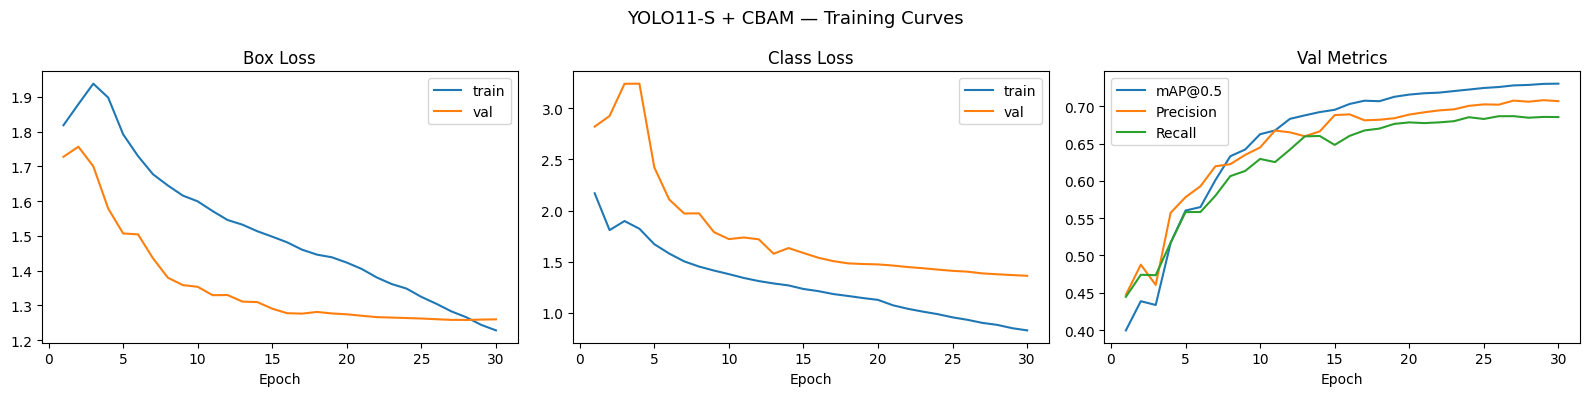

In [16]:
CBAM_DIR = "/kaggle/working/runs/yolo11s_cbam"
BEST_PT  = f"{CBAM_DIR}/weights/best.pt"

df = pd.read_csv(f"{CBAM_DIR}/results.csv")
df.columns = df.columns.str.strip()

print("── Per-epoch summary ──────────────────────────────────────────")
print(df[["epoch",
          "train/box_loss", "val/box_loss",
          "metrics/mAP50(B)",
          "metrics/precision(B)",
          "metrics/recall(B)"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("YOLO11-S + CBAM — Training Curves", fontsize=13)

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val")
axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val")
axes[1].set_title("Class Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],     label="mAP@0.5")
axes[2].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
axes[2].plot(df["epoch"], df["metrics/recall(B)"],    label="Recall")
axes[2].set_title("Val Metrics"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/cbam_training_curves.png", dpi=120)
plt.show()

---
## 13. Evaluation

Three evaluation passes:
- **Eval A** — D-Fire test set (3,754 images) — cross-dataset generalization
- **Eval B** — Combined val set (7,025 images) — all three source distributions
- **Eval C** — PyroNear val only — in-distribution tower camera performance

In [17]:
# Full memory reset before evaluation
try:
    del cbam_model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB ✅")

eval_model = YOLO(BEST_PT)
lbl_test   = Path(f"{UNIFIED}/labels/test")
img_test   = Path(f"{UNIFIED}/images/test")
lbl_val    = Path(f"{UNIFIED}/labels/val")
img_val    = Path(f"{UNIFIED}/images/val")


def batched_fp_rate(model, hard_neg_imgs, batch_size=200):
    """Compute FP rate on hard negative images in batches to avoid OOM."""
    fp = 0
    for i in range(0, len(hard_neg_imgs), batch_size):
        preds = model.predict(source=hard_neg_imgs[i:i+batch_size],
                              imgsz=640, conf=0.25, device=0, verbose=False)
        fp += sum(1 for r in preds if len(r.boxes) > 0)
        torch.cuda.empty_cache()
    return fp, fp / len(hard_neg_imgs) if hard_neg_imgs else 0


def get_hard_negs(img_dir, lbl_dir):
    return [
        str(img_dir / lbl.with_suffix(".jpg").name)
        for lbl in lbl_dir.glob("*.txt")
        if lbl.read_text().strip() == ""
        and (img_dir / lbl.with_suffix(".jpg").name).exists()
    ]

VRAM free: 15.4 GB ✅


In [18]:
# ════════════════════════════════════════════════════════════════════
# EVAL A — D-Fire Test Set
# ════════════════════════════════════════════════════════════════════
print("── EVAL A: D-Fire Test Set ────────────────────────────────────")
metrics_A = eval_model.val(
    data     = "/kaggle/working/data.yaml",
    split    = "test",
    imgsz    = 640,
    batch    = 8,
    device   = 0,
    plots    = True,
    project  = CBAM_DIR,
    name     = "eval_A_dfire_test",
    exist_ok = True,
)

map50_A, map5095_A = metrics_A.box.map50, metrics_A.box.map
prec_A,  rec_A     = metrics_A.box.mp,    metrics_A.box.mr

print(f"  mAP@0.5      : {map50_A:.4f}")
print(f"  mAP@0.5:0.95 : {map5095_A:.4f}")
print(f"  Precision    : {prec_A:.4f}")
print(f"  Recall       : {rec_A:.4f}")
print("  Per-class AP@0.5:")
for i, cls in enumerate(["smoke", "fire"]):
    print(f"    {cls:6s}: {metrics_A.box.ap50[i]:.4f}")

hard_neg_A       = get_hard_negs(img_test, lbl_test)
fp_A, fp_rate_A  = batched_fp_rate(eval_model, hard_neg_A)
print(f"\n  Hard negatives: {len(hard_neg_A)}")
print(f"  False positives: {fp_A}")
print(f"  FP Rate        : {fp_rate_A:.4f} ({fp_rate_A*100:.1f}%)")

── EVAL A: D-Fire Test Set ────────────────────────────────────
Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s_cbam summary (fused): 109 layers, 9,446,440 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 14.0±3.5 MB/s, size: 102.6 KB)
val: Scanning /kaggle/working/unified_dataset/labels/test... 3754 images, 2005 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3754/3754 785.0it/s 4.8s
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11243.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11244.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11245.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11313.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11315.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dat

In [19]:
# ════════════════════════════════════════════════════════════════════
# EVAL B — Combined Val Set
# ════════════════════════════════════════════════════════════════════
print("── EVAL B: Combined Val Set ───────────────────────────────────")
torch.cuda.empty_cache()
metrics_B = eval_model.val(
    data     = "/kaggle/working/data.yaml",
    split    = "val",
    imgsz    = 640,
    batch    = 8,
    device   = 0,
    plots    = True,
    project  = CBAM_DIR,
    name     = "eval_B_combined_val",
    exist_ok = True,
)

map50_B, map5095_B = metrics_B.box.map50, metrics_B.box.map
prec_B,  rec_B     = metrics_B.box.mp,    metrics_B.box.mr

print(f"  mAP@0.5      : {map50_B:.4f}")
print(f"  mAP@0.5:0.95 : {map5095_B:.4f}")
print(f"  Precision    : {prec_B:.4f}")
print(f"  Recall       : {rec_B:.4f}")
print("  Per-class AP@0.5:")
for i, cls in enumerate(["smoke", "fire"]):
    print(f"    {cls:6s}: {metrics_B.box.ap50[i]:.4f}")

hard_neg_B       = get_hard_negs(img_val, lbl_val)
fp_B, fp_rate_B  = batched_fp_rate(eval_model, hard_neg_B)
print(f"\n  Hard negatives: {len(hard_neg_B)}")
print(f"  False positives: {fp_B}")
print(f"  FP Rate        : {fp_rate_B:.4f} ({fp_rate_B*100:.1f}%)")

── EVAL B: Combined Val Set ───────────────────────────────────
Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1799.3±945.0 MB/s, size: 187.1 KB)
val: Scanning /kaggle/working/unified_dataset/labels/val.cache... 7025 images, 2129 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7025/7025 2.3Git/s 0.0s
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07536.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07539.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07561.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 879/879 13.9it/s 1:03
                   all       7025       7079      0.708      0.687      0.731      0.428
                 smoke       4733       5668      0.704      0.724      0.742      0.456
          

In [20]:
# ════════════════════════════════════════════════════════════════════
# EVAL C — PyroNear Val Only (tower camera, in-distribution)
# ════════════════════════════════════════════════════════════════════
print("── EVAL C: PyroNear Val (tower cameras) ───────────────────────")
pyro_val_imgs = sorted(img_val.glob("pyro_*.jpg"))
pyro_val_lbls = [lbl_val / p.with_suffix(".txt").name for p in pyro_val_imgs]
pyro_pos      = sum(1 for l in pyro_val_lbls if l.exists() and l.read_text().strip())
pyro_neg      = sum(1 for l in pyro_val_lbls if l.exists() and not l.read_text().strip())
print(f"  Total images    : {len(pyro_val_imgs)}")
print(f"  Positives       : {pyro_pos}")
print(f"  Hard negatives  : {pyro_neg}")

tp_C = fp_C = fn_C = 0
BATCH = 200
for i in range(0, len(pyro_val_imgs), BATCH):
    chunk_imgs = [str(p) for p in pyro_val_imgs[i:i+BATCH]]
    chunk_lbls = pyro_val_lbls[i:i+BATCH]
    preds = eval_model.predict(source=chunk_imgs, imgsz=640,
                               conf=0.25, device=0, verbose=False)
    for pred, lbl_path in zip(preds, chunk_lbls):
        has_gt  = lbl_path.exists() and lbl_path.read_text().strip() != ""
        has_det = len(pred.boxes) > 0
        if     has_gt and     has_det: tp_C += 1
        elif   has_gt and not has_det: fn_C += 1
        elif not has_gt and   has_det: fp_C += 1
    torch.cuda.empty_cache()

fp_rate_C = fp_C / pyro_neg if pyro_neg else 0
recall_C  = tp_C / pyro_pos if pyro_pos else 0
print(f"\n  True Positives     : {tp_C}")
print(f"  False Positives    : {fp_C}")
print(f"  False Negatives    : {fn_C}")
print(f"  FP Rate            : {fp_rate_C:.4f} ({fp_rate_C*100:.1f}%)")
print(f"  Image-level Recall : {recall_C:.4f} ({recall_C*100:.1f}%)")

── EVAL C: PyroNear Val (tower cameras) ───────────────────────
  Total images    : 4099
  Positives       : 3345
  Hard negatives  : 754

  True Positives     : 3026
  False Positives    : 453
  False Negatives    : 319
  FP Rate            : 0.6008 (60.1%)
  Image-level Recall : 0.9046 (90.5%)


---
## 14. Results Summary & Save

In [21]:
print("\n" + "="*65)
print(" RESULTS — YOLO11-S + CBAM")
print("="*65)
print(f"  {'Eval':<35} {'mAP@0.5':>8} {'Prec':>8} {'Rec':>8} {'FP Rate':>8}")
print(f"  {'-'*65}")
print(f"  {'A: D-Fire test  (cross-dataset)':<35} {map50_A:>8.4f} {prec_A:>8.4f} {rec_A:>8.4f} {fp_rate_A:>8.4f}")
print(f"  {'B: Combined val (all datasets)':<35} {map50_B:>8.4f} {prec_B:>8.4f} {rec_B:>8.4f} {fp_rate_B:>8.4f}")
print(f"  {'C: PyroNear val (tower only)':<35} {'—':>8} {'—':>8} {recall_C:>8.4f} {fp_rate_C:>8.4f}")
print("="*65)

cbam_results = {
    "model"                   : "YOLO11-S + CBAM",
    "train_data"              : "unified (55,698)",
    "params"                  : "~9.4M + CBAM",
    # Eval A
    "mAP50_dfire_test"        : round(float(map50_A),    4),
    "mAP5095_dfire_test"      : round(float(map5095_A),  4),
    "precision_dfire_test"    : round(float(prec_A),     4),
    "recall_dfire_test"       : round(float(rec_A),      4),
    "fp_rate_dfire_test"      : round(float(fp_rate_A),  4),
    "ap50_smoke_dfire"        : round(float(metrics_A.box.ap50[0]), 4),
    "ap50_fire_dfire"         : round(float(metrics_A.box.ap50[1]), 4),
    # Eval B
    "mAP50_combined_val"      : round(float(map50_B),    4),
    "mAP5095_combined_val"    : round(float(map5095_B),  4),
    "precision_combined_val"  : round(float(prec_B),     4),
    "recall_combined_val"     : round(float(rec_B),      4),
    "fp_rate_combined_val"    : round(float(fp_rate_B),  4),
    "ap50_smoke_combined"     : round(float(metrics_B.box.ap50[0]), 4),
    "ap50_fire_combined"      : round(float(metrics_B.box.ap50[1]), 4),
    # Eval C
    "recall_pyronear_val"     : round(float(recall_C),   4),
    "fp_rate_pyronear_val"    : round(float(fp_rate_C),  4),
    "tp_pyronear"             : int(tp_C),
    "fp_pyronear"             : int(fp_C),
    "fn_pyronear"             : int(fn_C),
}

results_csv = "/kaggle/working/cbam_results.csv"
pd.DataFrame([cbam_results]).to_csv(results_csv, index=False)
print(f"\nResults saved to {results_csv} ✅")

for k, v in cbam_results.items():
    print(f"  {k:<35}: {v}")


 RESULTS — YOLO11-S + CBAM
  Eval                                 mAP@0.5     Prec      Rec  FP Rate
  -----------------------------------------------------------------
  A: D-Fire test  (cross-dataset)       0.7550   0.7678   0.6736   0.0219
  B: Combined val (all datasets)        0.7308   0.7085   0.6874   0.2269
  C: PyroNear val (tower only)               —        —   0.9046   0.6008

Results saved to /kaggle/working/cbam_results.csv ✅
  model                              : YOLO11-S + CBAM
  train_data                         : unified (55,698)
  params                             : ~9.4M + CBAM
  mAP50_dfire_test                   : 0.755
  mAP5095_dfire_test                 : 0.4218
  precision_dfire_test               : 0.7678
  recall_dfire_test                  : 0.6736
  fp_rate_dfire_test                 : 0.0219
  ap50_smoke_dfire                   : 0.7958
  ap50_fire_dfire                    : 0.7142
  mAP50_combined_val                 : 0.7308
  mAP5095_combined_val   

In [22]:
# ── Final zip of all outputs ──────────────────────────────────────────
shutil.make_archive("/kaggle/working/yolo11s_cbam_full", "zip",
                    "/kaggle/working/runs/yolo11s_cbam")
print("Full run directory zipped to yolo11s_cbam_full.zip ✅")

print("\nSaved files:")
for f in sorted(Path(CBAM_DIR).rglob("*")):
    if f.is_file():
        size = f.stat().st_size / 1024 / 1024
        print(f"  {f.relative_to(CBAM_DIR)} ({size:.1f} MB)")

Full run directory zipped to yolo11s_cbam_full.zip ✅

Saved files:
  BoxF1_curve.png (0.1 MB)
  BoxPR_curve.png (0.1 MB)
  BoxP_curve.png (0.1 MB)
  BoxR_curve.png (0.1 MB)
  args.yaml (0.0 MB)
  confusion_matrix.png (0.1 MB)
  confusion_matrix_normalized.png (0.1 MB)
  eval_A_dfire_test/BoxF1_curve.png (0.1 MB)
  eval_A_dfire_test/BoxPR_curve.png (0.1 MB)
  eval_A_dfire_test/BoxP_curve.png (0.1 MB)
  eval_A_dfire_test/BoxR_curve.png (0.1 MB)
  eval_A_dfire_test/confusion_matrix.png (0.1 MB)
  eval_A_dfire_test/confusion_matrix_normalized.png (0.1 MB)
  eval_A_dfire_test/val_batch0_labels.jpg (0.2 MB)
  eval_A_dfire_test/val_batch0_pred.jpg (0.2 MB)
  eval_A_dfire_test/val_batch1_labels.jpg (0.2 MB)
  eval_A_dfire_test/val_batch1_pred.jpg (0.2 MB)
  eval_A_dfire_test/val_batch2_labels.jpg (0.2 MB)
  eval_A_dfire_test/val_batch2_pred.jpg (0.2 MB)
  eval_B_combined_val/BoxF1_curve.png (0.1 MB)
  eval_B_combined_val/BoxPR_curve.png (0.1 MB)
  eval_B_combined_val/BoxP_curve.png (0.1 MB)
  